<a href="https://colab.research.google.com/github/RadhaKalluri/Nowak-Kalluri_TypeIISGN2026/blob/main/Copy_of_TypeIandIIPulseTrainPaperVersionFinal6_30_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#install necessary plugins
!pip install --quiet --upgrade --force-reinstall numpy==1.24.4 scipy==1.11.4 pandas==2.2.2

# Start fresh
!pip install --upgrade pip setuptools wheel


!pip install --quiet brian2 brian2tools matplotlib-venn

  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> No available output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
ERROR: Failed to build 'numpy' when getting requirements to build wheel


In [ ]:
#establish channel parameters
from brian2 import *

defaultclock.dt = 0.01*ms
start_scope()
# Channels
Eh = -43*mV
EK = -81*mV
El = -65*mV
ENa = 81*mV

#Rothman and Manis Parameters
nf = 0.85  # proportion of n vs p kinetics
zss = 0.5 # steady state inactivation of glt
zssi = 1 # fully inactivating steady state for glt
temp = 22.  # temperature in degree celcius
q10 = 3. ** ((temp - 22) / 10.)
# hcno current (octopus cell)
frac = 0.0
qt = 4.5 ** ((temp - 33.) / 10.)

# Depolarized threshold Na channel  #This implementation incorporates the tweaks from Kalluri and Hight
eqs_nad = """
ina = gnadbar*m**3*h*(ENa-v) : amp/metre**2
dm/dt=q10*(minf-m)/mtau : 1
dh/dt=q10*(hinf-h)/htau : 1
minf = 1./(1+exp(-(vu + 38.) / 4)) : 1
hinf = 1./(1+exp((vu + 65.) / 6.)) : 1
mtau = ((10. / (5*exp((vu+60.) / 18.) + 36.*exp(-(vu+60.) / 25.))) + 0.04)*ms : second
htau = ((100. / (7*exp((vu+60.) / 11.) + 10.*exp(-(vu+60.) / 25.))) + 0.6)*ms : second
gnadbar: siemens/metre**2
"""

# KHT channel (delayed-rectifier K+); note that ptau is different than in the implementation shown in Brian for Rothman and Manis ptau = ((100. / (4*exp((vu+60) / 32.) + 5*exp(-(vu+60) / 22.))) + 5)*ms : second
eqs_kht = """
ikht = gkhtbar*(nf*n**2 + (1-nf)*p)*(EK-v) : amp/metre**2
dn/dt=q10*(ninf-n)/ntau : 1
dp/dt=q10*(pinf-p)/ptau : 1
ninf =   (1 + exp(-(vu + 15) / 5.))**-0.5 : 1
pinf =  1. / (1 + exp(-(vu + 23) / 6.)) : 1
ntau =  ((100. / (11*exp((vu+60) / 24.) + 21*exp(-(vu+60) / 23.))) + 0.7)*ms : second
ptau = ((100. / (4*exp((vu+60) / 32.) + 16*exp(-(vu+60) / 22.))) + 5)*ms : second
gkhtbar: siemens/metre**2
"""
# Ih channel (subthreshold adaptive, non-inactivating)
eqs_ih = """
ih = ghbar*r*(Eh-v) : amp/metre**2
dr/dt=q10*(rinf-r)/rtau : 1
rinf = 1. / (1+exp((vu + 95.) / 7.)) : 1
rtau = ((100000. / (237.*exp((vu+60.) / 12.) + 17.*exp(-(vu+60.) / 14.))) + 25.)*ms : second
ghbar: siemens/metre**2
"""

# KLT channel (low threshold K+)#winf = (1. / (1 + exp(-(vu + 48.) / 6.)))**0.25 : 1
eqs_klt = """
iklt = gkltbar*w**4*z*(EK-v) : amp/metre**2
dw/dt=q10*(winf-w)/wtau : 1
dz/dt=q10*(zinf-z)/ztau : 1
winf = (1. / (1 + exp(-(vu + 48.) /8.)))**0.25 : 1
zinf = zss + ((1.-zss) / (1 + exp((vu + 71.) / 10.))) : 1
wtau = ((100. / (6.*exp((vu+60.) / 6.) + 16.*exp(-(vu+60.) / 45.))) + 1.5)*ms : second
ztau = ((1000. / (exp((vu+60.) / 20.) + exp(-(vu+60.) / 8.))) + 50)*ms : second
gkltbar: siemens/metre**2
"""

# KLT channel (low threshold K+)#winf = (1. / (1 + exp(-(vu + 48.) / 6.)))**0.25 : 1
eqs_klti = """
iklti = gkltibar*ww**4*zz*(EK-v) : amp/metre**2
dww/dt=q10*(wwinf-ww)/wwtau : 1
dzz/dt=q10*(zzinf-zz)/zztau : 1
wwinf = (1. / (1 + exp(-(vu + 48.) /8.)))**0.25 : 1
zzinf = zssi + ((1.-zssi) / (1 + exp((vu + 71.) / 10.))) : 1
wwtau = ((100. / (6.*exp((vu+60.) / 6.) + 16.*exp(-(vu+60.) / 45.))) + 1.5)*ms : second
zztau = ((1000. / (exp((vu+60.) / 20.) + exp(-(vu+60.) / 8.))) + 50)*ms : second
gkltibar: siemens/metre**2
"""

# Ka channel (transient K+)
eqs_ka = """
ika = gkabar*a**3*b*(EK-v): amp/metre**2
da/dt=q10*(ainf-a)/atau : 1
db/dt=q10*(binf-b)/btau : 1
ainf = (1. / (1 + exp(-(vu + 12) / 12.)))**0.33 : 1
binf = 1. / (1 + exp((vu + 76) / 20.)) : 1
atau = 1.5 *ms: second
btau = (6 + 20/(1 + exp((vu + 20)/10)))*ms : second
gkabar: siemens/metre**2
"""

# Leak
eqs_leak = """
ileak = gl*(El-v) : amp/metre**2
gl: siemens/metre**2
"""


In [ ]:
#setup equation for estimating current/voltage
C = 1*uF/cm**2
eqs_common = """
dv/dt = (1/C)*(ileak + ina + ikht + iklt + ika + ih) + I/(C*S): volt
vu = v/mV : 1
I = I_timed(t, i) : amp
S : metre**2
"""

eqs_commoni = """
dv/dt = (1/C)*(ileak + ina + ikht + iklti + ika + ih) + I/(C*S): volt
vu = v/mV : 1
I = I_timed(t, i) : amp
S : metre**2
"""

dvdt_eq = '''
dvdt : volt/second
v_prev : volt
'''

eqs_dep = eqs_common + eqs_leak + eqs_nad + eqs_kht + eqs_klt + eqs_ka + eqs_ih
eqs_gkli = eqs_commoni + eqs_leak + eqs_nad + eqs_kht + eqs_klti + eqs_ka + eqs_ih

In [ ]:
#establish capacitance
Cp1 = 6.5*pF #type I and II-M example
Cp2 = 5.5*pF #type II-S example
#Cp3 = 19.2*pF #Type IIL example
S1 = Cp1/C
S2 = Cp2/C
#S3 = Cp3/C
refractory_period = 8*ms
v_thresh = -40*mV
dvdt_thresh = 20*mV/ms

In [ ]:
# Create a neuron groups with the desired number of neurons and conductances based on example empirical data for type I and type II SGNs
N = 40
eqs1 = eqs_dep + dvdt_eq
neurons1 = NeuronGroup(N, eqs1, threshold='v >= v_thresh', refractory='refractory_period', method='exponential_euler')
eqs2 = eqs_dep + dvdt_eq
neurons2 = NeuronGroup(N, eqs2, threshold='v >= v_thresh', refractory='refractory_period', method='exponential_euler')
eqs3 = eqs_dep + dvdt_eq
neurons3 = NeuronGroup(N, eqs3, threshold='v >= v_thresh', refractory='refractory_period', method='exponential_euler')
eqs4 = eqs_gkli + dvdt_eq
neurons4 = NeuronGroup(N, eqs4, threshold='v >= v_thresh', refractory='refractory_period', method='exponential_euler')
eqs5 = eqs_dep + dvdt_eq
neurons5 = NeuronGroup(N, eqs5, threshold='v >= v_thresh', refractory='refractory_period', method='exponential_euler')
eqs6 = eqs_dep + dvdt_eq
neurons6 = NeuronGroup(N, eqs6, threshold='v >= v_thresh', refractory='refractory_period', method='exponential_euler')
eqs7 = eqs_dep + dvdt_eq
neurons7 = NeuronGroup(N, eqs7, threshold='v >= v_thresh', refractory='refractory_period', method='exponential_euler')
eqs8 = eqs_gkli + dvdt_eq
neurons8 = NeuronGroup(N, eqs8, threshold='v >= v_thresh', refractory='refractory_period', method='exponential_euler')

#Type I Model 1: type I normal
neurons1.v = -65*mV
neurons1.S = S1
neurons1.gl = 0.03e-3*siemens/cm**2
neurons1.gnadbar = 3.61e-3*siemens/cm**2
neurons1.ghbar = .91e-3*siemens/cm**2
neurons1.gkhtbar = 2.09e-3*siemens/cm**2
neurons1.gkltbar = 2.09e-3*siemens/cm**2
neurons1.gkabar = 0.065e-3*siemens/cm**2
mon_s1 = StateMonitor(neurons1, ['v', 'I','ih','ina','ika'], record=True)
spikes1 = SpikeMonitor(neurons1)

#Type I Model 2: type I only gka
neurons2.v = -65*mV
neurons2.S = S1
neurons2.gl = 0.03e-3*siemens/cm**2
neurons2.gnadbar = 3.61e-3*siemens/cm**2
neurons2.ghbar = .91e-3*siemens/cm**2
neurons2.gkhtbar = 0e-3*siemens/cm**2 # 20 - 60 micro Siemens (Cp ranging from 6 - 10 pF; no correlation with NBP); 60uS/1e-5cm2 =
neurons2.gkltbar = 0e-3*siemens/cm**2
#neurons.gkltbar = array([0,1,2,4,5])*2.1e-3*siemens/cm**2   # 5-20 micro Siemens (Cp ranging from 6 - 10 pF, 1000um2=1e-5cm2)
neurons2.gkabar = 4.245e-3*siemens/cm**2
mon_s2 = StateMonitor(neurons2, ['v', 'I','ih','ina','ika'], record=True)
spikes2 = SpikeMonitor(neurons2)

#Type I Model: type I gka to gkh
neurons3.v = -65*mV  ## gmax; Type I: 2.86nS/pF  1uF/cm2  2.86e-3/cm2; Type II: 2nS/pF 2e-3/cm2, updated info median type I 3.448 nS/pF, type IIL is 3.367nS/pF, and type II s is  1.433
neurons3.S = S1     ## g-30; Type I: 1.25nS/pF (2.28 gmax/g-30)     Type II: 0.75 nS/pF (gmax/g-30 2.65) updated type I: 1.743 nS/pF,type IIL 1.099 nS/pF, and type IIs 0.458 nS/pF
neurons3.gl = 0.03e-3*siemens/cm**2
neurons3.gnadbar = 3.61e-3*siemens/cm**2
neurons3.ghbar = .91e-3*siemens/cm**2
neurons3.gkhtbar = 2.74e-3*siemens/cm**2 # 20 - 60 micro Siemens (Cp ranging from 6 - 10 pF; no correlation with NBP); 60uS/1e-5cm2 =
neurons3.gkltbar = 2.09e-3*siemens/cm**2
#neurons.gkltbar = array([0,1,2,4,5])*2.1e-3*siemens/cm**2   # 5-20 micro Siemens (Cp ranging from 6 - 10 pF, 1000um2=1e-5cm2)
neurons3.gkabar = 0e-3*siemens/cm**2
mon_s3 = StateMonitor(neurons3, ['v', 'I','ih','ina','ika'], record=True)
spikes3 = SpikeMonitor(neurons3)

#Type I Model: type I only gkli
neurons4.v = -65*mV  ## gmax; Type I: 2.86nS/pF  1uF/cm2  2.86e-3/cm2; Type II: 2nS/pF 2e-3/cm2, updated info median type I 3.448 nS/pF, type IIL is 3.367nS/pF, and type II s is  1.433
neurons4.S = S1     ## g-30; Type I: 1.25nS/pF (2.28 gmax/g-30)     Type II: 0.75 nS/pF (gmax/g-30 2.65) updated type I: 1.743 nS/pF,type IIL 1.099 nS/pF, and type IIs 0.458 nS/pF
neurons4.gl = 0.03e-3*siemens/cm**2
neurons4.gnadbar = 3.61e-3*siemens/cm**2
neurons4.ghbar = .91e-3*siemens/cm**2
neurons4.gkhtbar = 0e-3*siemens/cm**2 # 20 - 60 micro Siemens (Cp ranging from 6 - 10 pF; no correlation with NBP); 60uS/1e-5cm2 =
neurons4.gkltibar = 4.245e-3*siemens/cm**2
#neurons.gkltbar = array([0,1,2,4,5])*2.1e-3*siemens/cm**2   # 5-20 micro Siemens (Cp ranging from 6 - 10 pF, 1000um2=1e-5cm2)
neurons4.gkabar = 0e-3*siemens/cm**2
mon_s4 = StateMonitor(neurons4, ['v', 'I','ih','ina','ika'], record=True)
spikes4 = SpikeMonitor(neurons4)

#Type I Model: type II normal
neurons5.v = -65*mV  ## gmax; Type I: 2.86nS/pF  1uF/cm2  2.86e-3/cm2; Type II: 2nS/pF 2e-3/cm2, updated info median type I 3.448 nS/pF, type IIL is 3.367nS/pF, and type II s is  1.433
neurons5.S = S2    ## g-30; Type I: 1.25nS/pF (2.28 gmax/g-30)     Type II: 0.75 nS/pF (gmax/g-30 2.65) updated type I: 1.743 nS/pF,type IIL 1.099 nS/pF, and type IIs 0.458 nS/pF
neurons5.gl = 0.03e-3*siemens/cm**2
neurons5.gnadbar = 1.61e-3*siemens/cm**2
neurons5.ghbar = .91e-3*siemens/cm**2
neurons5.gkhtbar = 0.5e-3*siemens/cm**2 # 20 - 60 micro Siemens (Cp ranging from 6 - 10 pF; no correlation with NBP); 60uS/1e-5cm2 =
neurons5.gkltbar = 0.25e-3*siemens/cm**2
#neurons.gkltbar = array([0,1,2,4,5])*2.1e-3*siemens/cm**2   # 5-20 micro Siemens (Cp ranging from 6 - 10 pF, 1000um2=1e-5cm2)
neurons5.gkabar = 0.69e-3*siemens/cm**2
mon_s5 = StateMonitor(neurons5, ['v', 'I','ih','ina','ika'], record=True)
spikes5 = SpikeMonitor(neurons5)

#Type I Model: type II only gka
neurons6.v = -65*mV  ## gmax; Type I: 2.86nS/pF  1uF/cm2  2.86e-3/cm2; Type II: 2nS/pF 2e-3/cm2, updated info median type I 3.448 nS/pF, type IIL is 3.367nS/pF, and type II s is  1.433
neurons6.S = S2    ## g-30; Type I: 1.25nS/pF (2.28 gmax/g-30)     Type II: 0.75 nS/pF (gmax/g-30 2.65) updated type I: 1.743 nS/pF,type IIL 1.099 nS/pF, and type IIs 0.458 nS/pF
neurons6.gl = 0.03e-3*siemens/cm**2
neurons6.gnadbar = 1.61e-3*siemens/cm**2
neurons6.ghbar = .91e-3*siemens/cm**2
neurons6.gkhtbar = 0e-3*siemens/cm**2 # 20 - 60 micro Siemens (Cp ranging from 6 - 10 pF; no correlation with NBP); 60uS/1e-5cm2 =
neurons6.gkltbar = 0e-3*siemens/cm**2
#neurons.gkltbar = array([0,1,2,4,5])*2.1e-3*siemens/cm**2   # 5-20 micro Siemens (Cp ranging from 6 - 10 pF, 1000um2=1e-5cm2)
neurons6.gkabar = 1.44e-3*siemens/cm**2
mon_s6 = StateMonitor(neurons6, ['v', 'I','ih','ina','ika'], record=True)
spikes6 = SpikeMonitor(neurons6)

#Type I Model: type II gka to gkh
neurons7.v = -65*mV  ## gmax; Type I: 2.86nS/pF  1uF/cm2  2.86e-3/cm2; Type II: 2nS/pF 2e-3/cm2, updated info median type I 3.448 nS/pF, type IIL is 3.367nS/pF, and type II s is  1.433
neurons7.S = S2     ## g-30; Type I: 1.25nS/pF (2.28 gmax/g-30)     Type II: 0.75 nS/pF (gmax/g-30 2.65) updated type I: 1.743 nS/pF,type IIL 1.099 nS/pF, and type IIs 0.458 nS/pF
neurons7.gl = 0.03e-3*siemens/cm**2
neurons7.gnadbar = 1.61e-3*siemens/cm**2
neurons7.ghbar = .91e-3*siemens/cm**2
neurons7.gkhtbar = 1.19e-3*siemens/cm**2 # 20 - 60 micro Siemens (Cp ranging from 6 - 10 pF; no correlation with NBP); 60uS/1e-5cm2 =
neurons7.gkltbar = 0.25e-3*siemens/cm**2
#neurons.gkltbar = array([0,1,2,4,5])*2.1e-3*siemens/cm**2   # 5-20 micro Siemens (Cp ranging from 6 - 10 pF, 1000um2=1e-5cm2)
neurons7.gkabar = 0e-3*siemens/cm**2
mon_s7 = StateMonitor(neurons7, ['v', 'I','ih','ina','ika'], record=True)
spikes7 = SpikeMonitor(neurons7)

#Type I Model: type II only gkli
neurons8.v = -65*mV  ## gmax; Type I: 2.86nS/pF  1uF/cm2  2.86e-3/cm2; Type II: 2nS/pF 2e-3/cm2, updated info median type I 3.448 nS/pF, type IIL is 3.367nS/pF, and type II s is  1.433
neurons8.S = S2     ## g-30; Type I: 1.25nS/pF (2.28 gmax/g-30)     Type II: 0.75 nS/pF (gmax/g-30 2.65) updated type I: 1.743 nS/pF,type IIL 1.099 nS/pF, and type IIs 0.458 nS/pF
neurons8.gl = 0.03e-3*siemens/cm**2
neurons8.gnadbar = 1.61e-3*siemens/cm**2
neurons8.ghbar = .91e-3*siemens/cm**2
neurons8.gkhtbar = 0e-3*siemens/cm**2 # 20 - 60 micro Siemens (Cp ranging from 6 - 10 pF; no correlation with NBP); 60uS/1e-5cm2 =
neurons8.gkltibar = 1.44e-3*siemens/cm**2
#neurons.gkltbar = array([0,1,2,4,5])*2.1e-3*siemens/cm**2   # 5-20 micro Siemens (Cp ranging from 6 - 10 pF, 1000um2=1e-5cm2)
neurons8.gkabar = 0e-3*siemens/cm**2
mon_s8 = StateMonitor(neurons8, ['v', 'I','ih','ina','ika'], record=True)
spikes8 = SpikeMonitor(neurons8)



In [ ]:
# Define IstepIIL array with given values (in pA)
IstepIIL = np.array([
    -24.4140625, 1.831054688, 26.24511719, 50.65917969, 76.29394531,
    101.9287109, 127.5634766, 152.5878906, 177.6123047, 202.6367188,
    227.0507813, 252.0751953, 277.0996094, 302.1240234, 327.7587891,
    352.7832031, 378.4179688, 402.8320313, 427.8564453, 454.1015625
]) * pA  # Multiply by pA to give the correct units (picoamperes)

# Parameters
num_pulses = 50
pulse_duration = 3*ms
gap_duration = 7*ms
pre_time = 1000*ms
post_time = 1000*ms
defaultclock.dt = 0.01*ms
dt = defaultclock.dt
pulse_steps = int(pulse_duration / dt)
gap_steps = int(gap_duration / dt)
interval_steps = pulse_steps + gap_steps
pre_steps = int(pre_time / dt)
post_steps = int(post_time / dt)

# Total simulation time in steps
total_steps = pre_steps + num_pulses * interval_steps + post_steps

# Create current array with the correct units (ampere)
I_array = np.zeros((total_steps, len(IstepIIL))) * amp  # Use ampere (A) for current

# Fill pulse times with current
for i in range(num_pulses):
    start_idx = pre_steps + i * interval_steps
    I_array[start_idx : start_idx + pulse_steps, :] = IstepIIL  # Apply IstepIIL with units directly

# Create TimedArray
I_timed = TimedArray(I_array, dt=dt)

# You can now run your simulation
run((pre_time + num_pulses * interval_steps * dt + post_time))

WARNING    'i' is an internal variable of group 'neurongroup_1', but also exists in the run namespace with the value 49. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'neurongroup_2', but also exists in the run namespace with the value 49. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'neurongroup_3', but also exists in the run namespace with the value 49. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'neurongroup_4', but also exists in the run namespace with the value 49. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'i' is an internal variable of group 'neurongroup_5', but also exists in the run namespace with the value 49. The internal variable will 

Group 1 spike counts: [0, 0, 0, 0, 0, 0, 1, 3, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50]
Group 2 spike counts: [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Group 3 spike counts: [0, 0, 0, 0, 0, 0, 1, 3, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50, 50]
Group 4 spike counts: [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 50, 50, 50, 50, 50, 50, 50, 50, 50]
Group 5 spike counts: [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Group 6 spike counts: [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Group 7 spike counts: [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 2, 50, 50, 50, 50, 50, 50, 50, 50, 50]
Group 8 spike counts: [0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 34, 48, 49, 50, 50, 50, 50, 50]


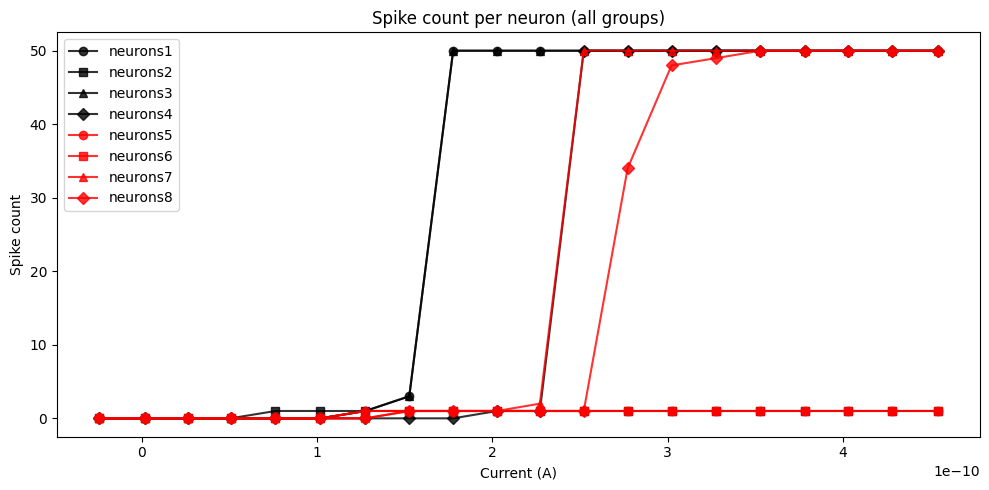

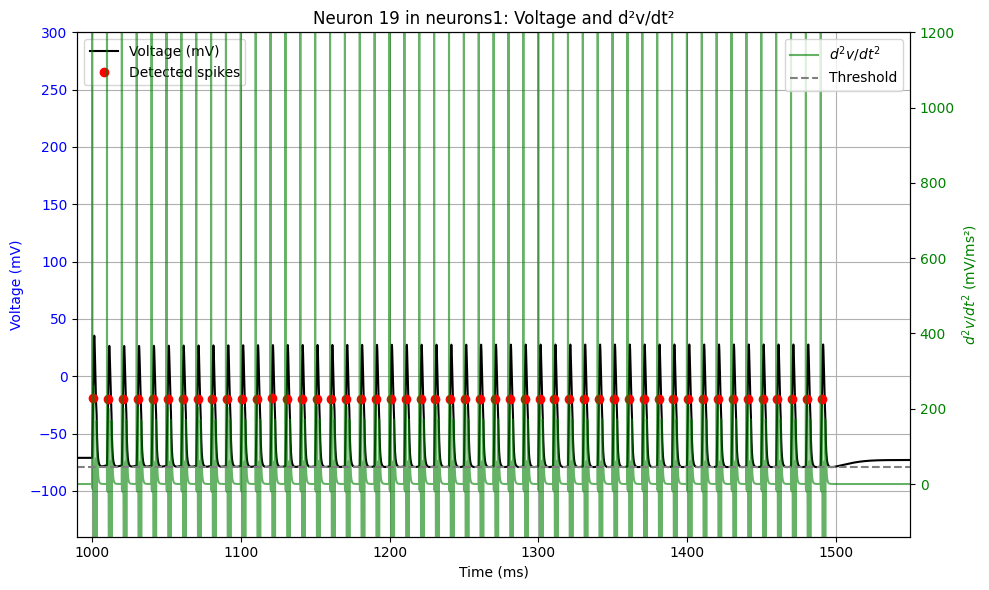

WARNING    /tmp/ipykernel_15857/829293598.py:133: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend()
 [py.warnings]
  ax2.legend()



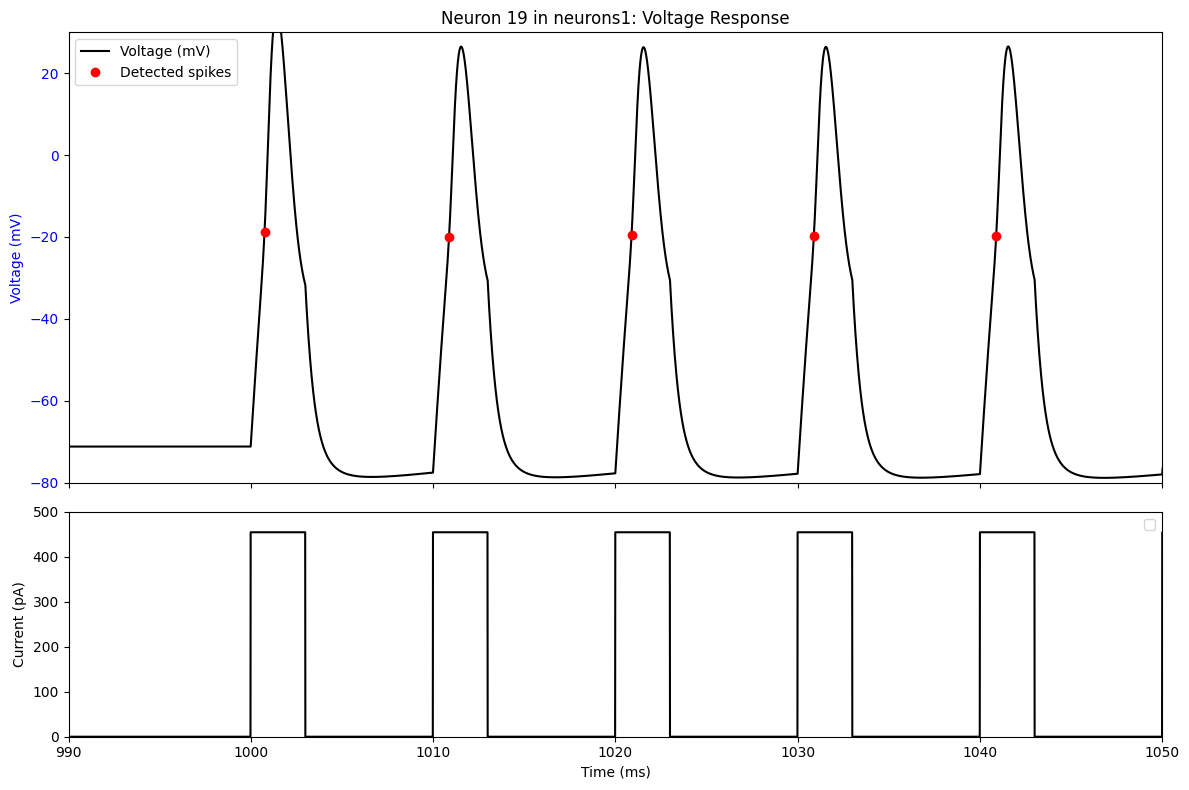

In [ ]:
#establish parameters for experimental stimulus
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.ndimage import binary_opening

voltage_vars = [mon_s1.v, mon_s2.v, mon_s3.v, mon_s4.v, mon_s5.v, mon_s6.v, mon_s7.v, mon_s8.v]
time_vars = [mon_s1.t, mon_s2.t, mon_s3.t, mon_s4.t, mon_s5.t, mon_s6.t, mon_s7.t, mon_s8.t]
labels = [f'neurons{i+1}' for i in range(8)]
n_neurons_train = 20

# Parameters for spike detection
v_thresh_spike = -45  # mV
ddv_thresh = 45  # mV/ms²
dvdt_thresh = 10  # mV/ms
min_interval = 5  # ms refractory period

# Store spike counts per neuron per group
all_spike_counts = []

plt.figure(figsize=(10, 5))
colors = ['black', 'black', 'black', 'black', 'red', 'red', 'red', 'red']  # One color per group
markers = ['o', 's', '^', 'D','o', 's', '^', 'D']               # One marker per group
offset = 0

for group_idx in range(8):
    voltage = voltage_vars[group_idx] / mV
    time = time_vars[group_idx] / ms
    dt = float(time[1] - time[0])
    n_neurons_train = 20
    spike_counts = []

    for neuron_idx in range(n_neurons_train):
        v = voltage[neuron_idx]
        dv_dt = np.gradient(v, dt)
        d2v_dt2 = np.gradient(dv_dt, dt)
        condition = (v > v_thresh_spike) & (d2v_dt2 > ddv_thresh) & (dv_dt > dvdt_thresh)
        # Remove isolated transient points (e.g., < 2 ms wide)
        condition = binary_opening(condition, structure=np.ones(int(.1/dt)))
        spike_indices, _ = find_peaks(condition.astype(float), distance=int(min_interval / dt))
        spike_counts.append(len(spike_indices))
        x_vals = IstepIIL

    all_spike_counts.append(spike_counts)
    print(f"Group {group_idx+1} spike counts: {spike_counts}")

    plt.plot(
        x_vals,
        spike_counts,
        marker=markers[group_idx],
        linestyle='-',
        color=colors[group_idx],
        label=labels[group_idx],
        alpha=0.8
    )

plt.xlabel("Current (A)")
plt.ylabel("Spike count")
plt.title("Spike count per neuron (all groups)")
plt.legend()
plt.tight_layout()
#plt.savefig("TypeIspike_counts_plot.pdf", format="pdf", bbox_inches="tight")
plt.show()


# Parameters: choose which group and neuron to visualize
group_to_plot = 1  # e.g., 1 for mon_s1, 2 for mon_s2, ..., 8 for mon_s8
neuron_to_plot = 19 # neuron index within the group (0-based)

# Extract voltage and time for the selected neuron
voltage = voltage_vars[group_to_plot - 1][neuron_to_plot] / mV
time = time_vars[group_to_plot - 1] / ms
dt = float(time[1] - time[0])

# Spike detection (same as before)
dv_dt = np.gradient(voltage, dt)
d2v_dt2 = np.gradient(dv_dt, dt)
condition = (voltage > v_thresh_spike) & (d2v_dt2 > ddv_thresh) & (dv_dt > dvdt_thresh)
condition = binary_opening(condition, structure=np.ones(int(.1/dt)))
spike_indices, _ = find_peaks(condition.astype(float), distance=min_interval / dt)
spike_times = time[spike_indices]
spike_voltages = voltage[spike_indices]


# Plot voltage trace and d²v/dt²
fig, ax1 = plt.subplots(figsize=(10, 6))


# Voltage trace
ax1.plot(time, voltage, label='Voltage (mV)', color='black')
ax1.plot(spike_times, spike_voltages, 'ro', label='Detected spikes')
#ax1.plot(time, ika, label='Ika', color='black')
ax1.set_xlabel('Time (ms)')
ax1.set_ylabel('Voltage (mV)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
axis([990, 1550, -140, 300])
ax1.legend(loc='upper left')
ax1.grid(True)

# Second derivative on secondary axis
ax2 = ax1.twinx()
ax2.plot(time, d2v_dt2, label=r'$d^2v/dt^2$', color='green', alpha=0.6)
ax2.axhline(ddv_thresh, color='gray', linestyle='--', label='Threshold')
ax2.set_ylabel(r'$d^2v/dt^2$ (mV/ms²)', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right')

plt.title(f'Neuron {neuron_to_plot} in {labels[group_to_plot - 1]}: Voltage and d²v/dt²')
axis([990, 1550, -140, 1200])
plt.tight_layout()
plt.show()

time_plot = np.arange(I_array.shape[0]) * defaultclock.dt / ms
curr = I_array[:, neuron_to_plot] / pA

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={'height_ratios': [2, 1]})

# Top: Voltage trace
ax1.plot(time, voltage, label='Voltage (mV)', color='black')
ax1.plot(spike_times, spike_voltages, 'ro', label='Detected spikes')
ax1.set_ylabel('Voltage (mV)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')
ax1.set_ylim([-80, 30])
plt.xlim([990, 1050])
ax1.set_title(f'Neuron {neuron_to_plot} in {labels[group_to_plot - 1]}: Voltage Response')

# Bottom: Current injection trace
ax2.plot(time_plot, I_array[:, neuron_to_plot] / pA, color='black')
ax2.set_ylabel('Current (pA)', color='black')
ax2.set_xlabel('Time (ms)')
ax2.tick_params(axis='y', labelcolor='black')
ax2.legend()
ax2.set_ylim([0, 500])
plt.xlim([990, 1050])
#axis([990, 1550, -4e-10, 4e-10])  # adjust this to match your voltage plot range
plt.tight_layout()
#plt.savefig("TypeIspike_counts_plotallzoom.pdf", format="pdf", bbox_inches="tight")
plt.show()

#from google.colab import files
#files.download("TypeIspike_counts_plotallzoom.pdf")